# KernelGap

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from config.config import *
from config.experiments import ExperimentConfig

from src.data.synthetic import *
from src.utils.visuals import *
from src.data.preprocessing import preprocess_synthetic
from src.optimization.classical_base import classical_benchmark
from src.data.saving import svm_exists, load_parameter_train
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results

## 0. Classical Benchmarking

With a random candidate

In [ ]:
skipfactor = np.linspace(2, 12, 11, dtype=int)
accuracies_classic, errs_classic = [], []
for skip in skipfactor:
    accs = []
    for seed in range(9):
        X, y = KernelGap_synthetic_dataset(seed=seed, skipfactor=skip, n_per_class=40)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_classic.append(np.mean(accs))
    errs_classic.append(np.std(accs))

data = {'skipfactor': skipfactor, 'acc classic': accuracies_classic, 'err classic': errs_classic}
df = pd.DataFrame(data)
df.to_csv('Results/KernelGap Benchmark/ClassicalPerformance.csv', index=False)

In [2]:
df = pd.read_csv('Results/KernelGap Benchmark/ClassicalPerformance.csv')
skipfactor, accuracies_classic, errs_classic = df['skipfactor'], df['acc classic'], df['err classic']

With a harder candidate (pre-selected)

In [9]:
candidate, g = find_hard_generating_candidate(n_candidates=20, seed=45)
skipfactor = np.linspace(2, 12, 11, dtype=int)
accuracies_classic_h, errs_classic_h = [], []
for skip in skipfactor:
    accs = []
    for seed in range(9):
        X, y = KernelGap_synthetic_dataset(seed=seed, skipfactor=skip, n_per_class=40, gen_candidate=candidate)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_classic_h.append(np.mean(accs))
    errs_classic_h.append(np.std(accs))

data = {'skipfactor': skipfactor, 'acc classic': accuracies_classic_h, 'err classic': errs_classic_h}
df = pd.DataFrame(data)
df.to_csv('Results/KernelGap Benchmark/ClassicalPerformance_Hard.csv', index=False)

Best of 20: g = 83.8441


In [3]:
df = pd.read_csv('Results/KernelGap Benchmark/ClassicalPerformance_Hard.csv')
skipfactor_h, accuracies_classic_h, errs_classic_h = df['skipfactor'], df['acc classic'], df['err classic']

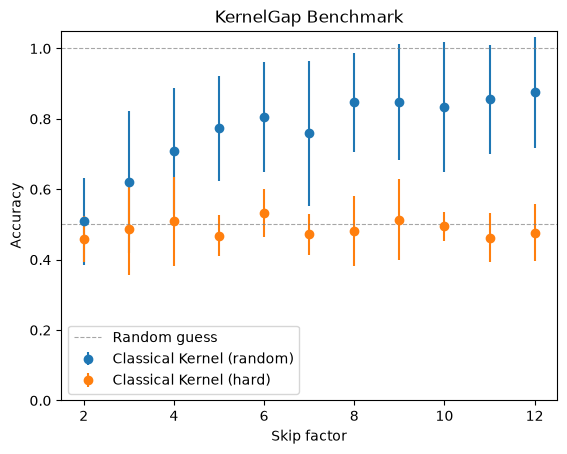

In [4]:
plt.title('KernelGap Benchmark')
plt.ylabel('Accuracy')
plt.xlabel('Skip factor')
plt.errorbar(skipfactor, accuracies_classic, yerr=errs_classic, fmt='o', color='tab:blue', label='Classical Kernel (random)')
plt.errorbar(skipfactor, accuracies_classic_h, yerr=errs_classic_h, fmt='o', color='tab:orange', label='Classical Kernel (hard)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

## 1. Quantum Optuna

In [11]:
config = ExperimentConfig(
    name = 'optuna kta 100 baseline',     # default parameters
    optimizer = 'optuna',
    variant = 'kta',
    subset_method = 'none',
    optimizer_kwargs = {'n_trials': 100},
)

skipfactor = [2, 4, 6, 8, 10, 12]
accuracies_optuna, errs_optuna = [], []
for skip in skipfactor:
    accs = []
    for seed in range(3):
        config.name = f'KernelGap Benchmark/optuna 100 d{skip} s{seed}'
        X, y = KernelGap_synthetic_dataset(seed=seed, skipfactor=skip, gen_candidate=candidate)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

        # run experiment
        trained_candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
        g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))

        # svm
        K_test = None
        if not svm_exists(config.name):
            print("Computing cross-kernel (test × subset)…")
            K_test = quantum_kernel_matrix_cross(X_test, X_sub, trained_candidate)
        results = get_svm_results(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])
    accuracies_optuna.append(np.mean(accs))
    errs_optuna.append(np.std(accs))
    

Loading cached candidate for 'KernelGap Benchmark/optuna 100 d2 s0'
Loading cached SVM results for 'KernelGap Benchmark/optuna 100 d2 s0'
Loading cached candidate for 'KernelGap Benchmark/optuna 100 d2 s1'
Loading cached SVM results for 'KernelGap Benchmark/optuna 100 d2 s1'
Loading cached candidate for 'KernelGap Benchmark/optuna 100 d2 s2'
Loading cached SVM results for 'KernelGap Benchmark/optuna 100 d2 s2'
Loading cached candidate for 'KernelGap Benchmark/optuna 100 d4 s0'
Loading cached SVM results for 'KernelGap Benchmark/optuna 100 d4 s0'
Loading cached candidate for 'KernelGap Benchmark/optuna 100 d4 s1'
Loading cached SVM results for 'KernelGap Benchmark/optuna 100 d4 s1'
Loading cached candidate for 'KernelGap Benchmark/optuna 100 d4 s2'
Loading cached SVM results for 'KernelGap Benchmark/optuna 100 d4 s2'
Loading cached candidate for 'KernelGap Benchmark/optuna 100 d6 s0'
Loading cached SVM results for 'KernelGap Benchmark/optuna 100 d6 s0'
Loading cached candidate for 'Kern

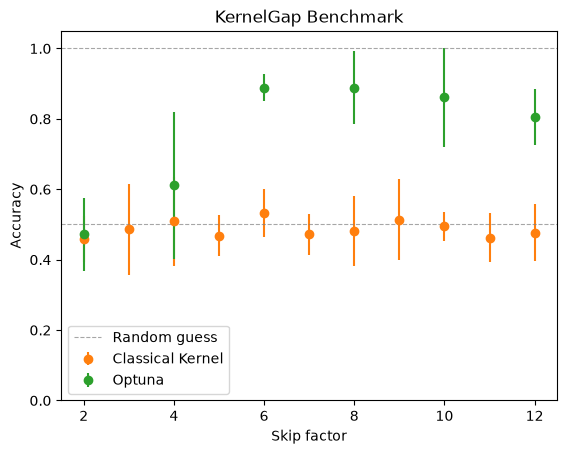

In [12]:
skipfactor_c = np.linspace(2, 12, 11, dtype=int)

plt.title('KernelGap Benchmark')
plt.ylabel('Accuracy')
plt.xlabel('Skip factor')

plt.errorbar(skipfactor_c, accuracies_classic_h, yerr=errs_classic_h, fmt='o', color='tab:orange', label='Classical Kernel')
plt.errorbar(skipfactor, accuracies_optuna, yerr=errs_optuna, fmt='o', color='tab:green', label='Optuna')

plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

## 2. Quantum Mealpy

In [8]:
candidate, g = find_hard_generating_candidate(n_candidates=20, seed=45)

config = ExperimentConfig(
    name = 'mealpy kta 30 baseline',      # default parameters
    optimizer = 'mealpy',
    variant = 'kta',
    subset_method = 'none',
    optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
)

skipfactor = [2, 4, 6, 8, 10, 12]
accuracies_mealpy, errs_mealpy = [], []
for skip in skipfactor:
    accs = []
    for seed in range(3):
        config.name = f'KernelGap Benchmark/mealpy 30 d{skip} s{seed}'
        X, y = KernelGap_synthetic_dataset(seed=seed, skipfactor=skip, gen_candidate=candidate)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

        # run experiment
        trained_candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
        g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))

        # svm
        K_test = None
        if not svm_exists(config.name):
            print("Computing cross-kernel (test × subset)…")
            K_test = quantum_kernel_matrix_cross(X_test, X_sub, trained_candidate)
        results = get_svm_results(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])
    accuracies_mealpy.append(np.mean(accs))
    errs_mealpy.append(np.std(accs))

Best of 20: g = 83.8441
Loading cached candidate for 'KernelGap Benchmark/mealpy 30 d2 s0'
Loading cached SVM results for 'KernelGap Benchmark/mealpy 30 d2 s0'
Loading cached candidate for 'KernelGap Benchmark/mealpy 30 d2 s1'
Loading cached SVM results for 'KernelGap Benchmark/mealpy 30 d2 s1'
Loading cached candidate for 'KernelGap Benchmark/mealpy 30 d2 s2'
Loading cached SVM results for 'KernelGap Benchmark/mealpy 30 d2 s2'
Loading cached candidate for 'KernelGap Benchmark/mealpy 30 d4 s0'
Loading cached SVM results for 'KernelGap Benchmark/mealpy 30 d4 s0'
Loading cached candidate for 'KernelGap Benchmark/mealpy 30 d4 s1'
Loading cached SVM results for 'KernelGap Benchmark/mealpy 30 d4 s1'
Loading cached candidate for 'KernelGap Benchmark/mealpy 30 d4 s2'
Loading cached SVM results for 'KernelGap Benchmark/mealpy 30 d4 s2'
Loading cached candidate for 'KernelGap Benchmark/mealpy 30 d6 s0'
Loading cached SVM results for 'KernelGap Benchmark/mealpy 30 d6 s0'
Loading cached candidate

2026/08/28 11:04:01 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=30, pop_size=20, pc=0.95, pm=0.1)


KeyboardInterrupt: 

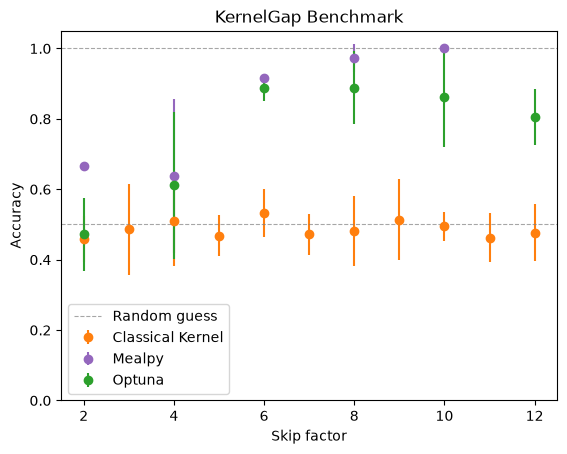

In [ ]:
skipfactor_c = np.linspace(2, 12, 11, dtype=int)

plt.title('KernelGap Benchmark')
plt.ylabel('Accuracy')
plt.xlabel('Skip factor')

plt.errorbar(skipfactor_c, accuracies_classic_h, yerr=errs_classic_h, fmt='o', color='tab:orange', label='Classical Kernel')
plt.errorbar(skipfactor[:len(accuracies_mealpy)], accuracies_mealpy, yerr=errs_mealpy, fmt='o', color='tab:purple', label='Mealpy')
plt.errorbar(skipfactor, accuracies_optuna, yerr=errs_optuna, fmt='o', color='tab:green', label='Optuna')

plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.ylim(0, 1.05)
plt.show()